In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd

burial_tables = pd.read_excel(
    "archy494data.xlsx",
    sheet_name="burialtables",
    skiprows=2
)

print(burial_tables.columns.tolist())

['Site', 'Sub-region', 'Adult Burials', 'Intramural', 'Extramural', 'Unknown Context', 'Pithos Burials', 'Cist Grave', 'Simple Internment', 'Refuse Pit', 'Other', 'Unknown', 'Notes']


In [3]:
burial_tables.columns = (
    burial_tables.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

In [4]:
import pandas as pd
import numpy as np

cols = [
    "adult_burials", "intramural", "extramural", "pithos_burials",
    "simple_internment", "refuse_pit", "other", "unknown"
]

burial_tables2 = burial_tables.copy()

# Drop embedded header rows
burial_tables2 = burial_tables2[burial_tables2["site"].ne("Site")].copy()

# Convert numeric columns safely
burial_tables2[cols] = (
    burial_tables2[cols]
    .replace("-", 0)
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)


/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_34980/79316401.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("-", 0)


In [5]:
import pandas as pd
import numpy as np

df = burial_tables.copy()
s = df["site"].astype(str)

is_subadult_marker = s.str.contains("Subadult", case=False, na=False)
df["age_group"] = np.where(is_subadult_marker.cumsum() > 0, "Subadult", "Adult")
df["age_group"] = df["age_group"].astype(str).str.strip()   # <-- normalize

bad_sites = {"Site", "Adults", "Subadults", "Table 1: Adult Burials", "Table 2: Subadult Burials"}
df = df[~df["site"].isin(bad_sites)].copy()
df = df.dropna(subset=["site", "sub_region"])

df["total"] = pd.to_numeric(df["adult_burials"].replace({"-": 0}), errors="coerce")
df = df.dropna(subset=["total"])

# Pivot
wide = df.pivot_table(
    index=["site", "sub_region"],
    columns="age_group",
    values="total",
    aggfunc="sum"
)

print("Pivot columns:", list(wide.columns))  # <-- you can delete once confirmed

# Guarantee both columns exist, in a fixed order
wide = wide.reindex(columns=["Adult", "Subadult"])

totals = wide.rename(columns={"Adult": "adult_total", "Subadult": "subadult_total"}).reset_index()

totals[["adult_total", "subadult_total"]] = totals[["adult_total", "subadult_total"]].fillna(0).astype(int)

totals.sort_values(["sub_region", "site"]).head(20)


Pivot columns: ['Adult', 'Subadult']


/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_34980/3549533122.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["total"] = pd.to_numeric(df["adult_burials"].replace({"-": 0}), errors="coerce")


age_group,site,sub_region,adult_total,subadult_total
6,Canhasan,Konya Plain,6,10
11,Kubad Abad,Konya Plain,0,2
17,Çatal Höyük West,Konya Plain,0,2
0,Alaca Höyük,Kızılırmak Curve,1,5
1,Alişar Höyük,Kızılırmak Curve,24,8
3,Boğazköy-Büyükkaya,Kızılırmak Curve,0,1
4,Boğazköy-Yarıkkaya,Kızılırmak Curve,0,0
5,Büyük Güllücek,Kızılırmak Curve,1,0
9,Kalınkaya-Toptaştepe,Kızılırmak Curve,16,18
13,Orman Fidanlığı,Kızılırmak Curve,0,1


In [6]:
print(df.groupby("age_group")["total"].count())

age_group
Adult       11
Subadult    17
Name: total, dtype: int64


In [7]:
analysis_df = totals.merge(
    burial_tables[[
        "site",
        "intramural",
        "extramural",
        "pithos_burials",
        "simple_internment",
        "refuse_pit",
        "other",
        "unknown"
    ]],
    on="site",
    how="left"
)

analysis_df = analysis_df.replace("-", 0)
analysis_df = analysis_df.apply(pd.to_numeric, errors="ignore")

/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_34980/4132838738.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  analysis_df = analysis_df.replace("-", 0)
/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_34980/4132838738.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  analysis_df = analysis_df.apply(pd.to_numeric, errors="ignore")


In [13]:
from matplotlib.colors import LinearSegmentedColormap

colors = ["#643690"
          , "#35303C"
          , "#35303C"
          , "#000000"
          , "#7E5C0A"
          , "#FCB813"]

husky_cmap = LinearSegmentedColormap.from_list("burialmap", colors)

husky_cmap = LinearSegmentedColormap.from_list("burialmap", colors[::-1])



/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_34980/3508784944.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"-": 0})


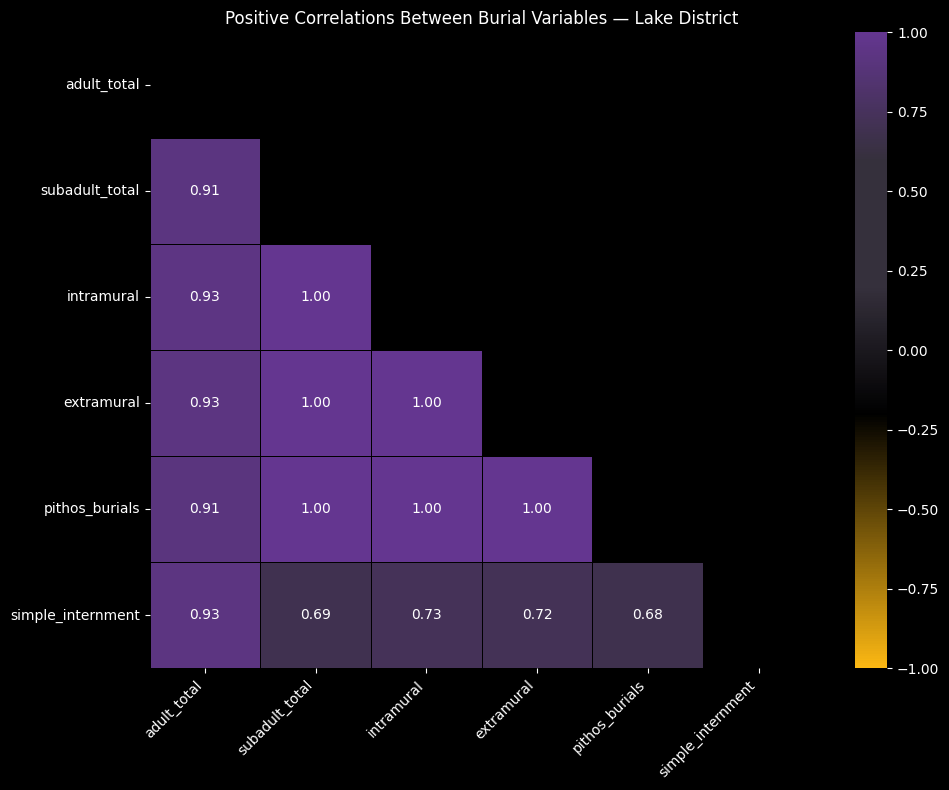

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# --------------------------
# 1) FILTER TO LAKE DISTRICT
# --------------------------
lake_totals = totals[totals["sub_region"] == "Lake District"].copy()
lake_df = df[df["sub_region"] == "Lake District"].copy()

# keep only real site rows
bad_sites = {"Site", "Adults", "Subadults", "Table 1: Adult Burials", "Table 2: Subadult Burials"}
lake_df = lake_df[~lake_df["site"].isin(bad_sites)].copy()

# --------------------------
# 2) CLEAN NUMERIC COLUMNS
#    (trim unknown/refuse/other here)
# --------------------------
burial_cols = [
    "intramural",
    "extramural",
    "pithos_burials",
    "simple_internment"
]

lake_df[burial_cols] = (
    lake_df[burial_cols]
    .replace({"-": 0})
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)

# if df still has one row per age-group section, collapse to one row per site
lake_practices = (
    lake_df.groupby(["site", "sub_region"])[burial_cols]
    .sum()
    .reset_index()
)

# --------------------------
# 3) MERGE TOTALS + PRACTICES
# --------------------------
lake_analysis = lake_totals.merge(
    lake_practices,
    on=["site", "sub_region"],
    how="left"
)

# --------------------------
# 4) CORRELATION MATRIX
# --------------------------
corr_lake = lake_analysis.select_dtypes(include="number").corr()

# --------------------------
# 5) MASKING LOGIC
# --------------------------
mask_lake = np.zeros_like(corr_lake, dtype=bool)

# mask the entire row "adult_total"
#mask_lake[corr_lake.index == "adult_total", :] = True

# mask correlations <= 0
#mask_lake |= (corr_lake <= 0)

# mask duplicate triangle
mask_lake |= np.triu(np.ones_like(corr_lake, dtype=bool))

# normalize to visible positive range
#norm_lake = Normalize(vmin=0, vmax=corr_lake.where(~mask_lake).max().max())

# --------------------------
# 6) PLOT
# --------------------------
with plt.style.context("dark_background"):

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        corr_lake,
        mask=mask_lake,
        cmap=husky_cmap,
        #norm=norm_lake,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        linecolor="k",
        linewidths=0.5
    )

    plt.title("Positive Correlations Between Burial Variables — Lake District")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()